# Bayesian M2M Gaussian experiment

This notebook is only the experiment driver and plotting layer.

The computational stages are separate scripts:

1. Generate and freeze \(D=\{(X^i,Y^i)\}_{i=1}^n\) and a separate unseen \((X^0,Y^0)\).
2. Call `collect_pca_trajectory_fixed.py` to pretrain and construct the PCA subspace from this fixed \(D\).
3. Call `run_ess.py` to sample the posterior PCA coordinates \(\phi\).
4. Call `posterior_predictive.py` to evaluate the posterior predictive at \(X^0\).

The notebook produces:
- a pair plot of the \(K\) posterior coordinates \(\phi\);
- the posterior predictive distribution of the target mean \(m_\phi(X^0)\).


In [1]:
!git clone https://github.com/djskog/simple_gaussian_example.git/

Cloning into 'simple_gaussian_example'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 121 (delta 63), reused 93 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (121/121), 8.12 MiB | 32.10 MiB/s, done.
Resolving deltas: 100% (63/63), done.


In [2]:
!git -C /content/simple_gaussian_example pull

Already up to date.


In [3]:
from pathlib import Path
import sys
import subprocess
import random

import numpy as np
import torch
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount("/content/drive")
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/simple_gaussian_example"
)

# ------------------------------------------------------------
# Project setup
# ------------------------------------------------------------

# In Colab, make sure the notebook is running from the repository root.
%cd /content/simple_gaussian_example
PROJECT_ROOT = Path.cwd()

print("Working directory:", PROJECT_ROOT)

# Check that the project files are actually here.
required_files = [
    "datasets.py",
    "utils.py",
    "collect_pca_trajectory.py",
    "run_ess.py",
    "posterior_predictive.py",
]

missing = [f for f in required_files if not (PROJECT_ROOT / f).exists()]

if missing:
    raise FileNotFoundError(
        "Missing project files:\n" + "\n".join(f"  - {f}" for f in missing)
    )

# Make local project modules importable.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datasets import generate_location_data
from utils import bayes_optimal_target_mean, get_df_label

# Output directories
CHECKPOINT_DIR = DRIVE_ROOT / "checkpoints"
FIGURE_DIR = DRIVE_ROOT / "figures"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Drive root:", DRIVE_ROOT)
print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
/content/simple_gaussian_example
Working directory: /content/simple_gaussian_example
Drive root: /content/drive/MyDrive/simple_gaussian_example
Project root: /content/simple_gaussian_example
Python: /usr/bin/python3
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [22]:
# Experiment configuration

SEED = 7

N_TRAIN_MEASURES = 500
N_TEST_MEASURES = 10
N_POINTS = 128

beta = torch.tensor([2.0, 2.0])
Sigma_Z = torch.eye(2)
Sigma_X = torch.eye(2)
Sigma_Y = 0.5 * torch.eye(2)
B0 = torch.tensor([
    [1.0, 0.0],
    [0.0, 0.0],
    ])

T_DFs = [np.inf, 3.0, 4.0, 5.0, 8.0, 12.0, 20.0, 50.0]  

# PCA trajectory
PRETRAIN_EPOCHS = 50
PRETRAIN_LR = 1e-3
TRAJECTORY_EPOCHS = 50
TRAJECTORY_LR = 1e-2
MAX_SNAPSHOTS = 20
PCA_RANK = 5
BATCH_SIZE = 64

# ESS
PRIOR_STD = 1
ESS_BURN_IN = 100
ESS_NUM_SAMPLES = 1000
ESS_THIN = 1
ESS_TEMPERATURE = 1e5
ESS_SEED = 1234

## 1. Generate and freeze \(D\) and an unseen test pair

We materialize the observations once. The later PCA and ESS scripts use these exact tensors, so the likelihood is deterministic conditional on the fixed dataset.


In [14]:
#generate and save D
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

for df in T_DFs:
    data = generate_location_data(
        num_measures=N_TRAIN_MEASURES,
        num_points=N_POINTS,
        df=df,
        beta=beta,
        Sigma_Z=Sigma_Z,
        Sigma_X=Sigma_X,
        Sigma_Y=Sigma_Y,
        B0=B0,
        seed=SEED,
    )
    
    path = (CHECKPOINT_DIR / f"{get_df_label(df)}_fixed_D.pt")
    torch.save(data, path)
    print("Saved:", path)




Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df3_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df4_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df5_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df8_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df12_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df20_fixed_D.pt
Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/t_df50_fixed_D.pt


In [15]:
#generate and save X0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

test_data = generate_location_data(
        num_measures=N_TEST_MEASURES,
        num_points=N_POINTS,
        df=np.inf,  # Gaussian case
        beta=beta,
        Sigma_Z=Sigma_Z,
        Sigma_X=Sigma_X,
        Sigma_Y=Sigma_Y,
        B0=B0,
        seed=SEED,
    )

path = (CHECKPOINT_DIR / f"{get_df_label(np.inf)}_fixed_data.pt")
torch.save(test_data, path)
print("Saved:", path)

Saved: /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_fixed_data.pt


## 2. Construct the PCA subspace

The separate collector starts from a fresh transformer, pretrains on the fixed \(D\), continues with constant-step-size SGD, forms the SWA shift \(\hat w\), and computes the scaled PCA basis \(P\), giving

\[
w(\phi)=\hat w+P\phi.
\]


In [16]:
pca_script = PROJECT_ROOT / "collect_pca_trajectory.py"

if not pca_script.exists():
    raise FileNotFoundError(f"Missing {pca_script}")

for df in T_DFs:
    train_data_path = CHECKPOINT_DIR / f"{get_df_label(df)}_fixed_D.pt"
    pca_path = CHECKPOINT_DIR / f"{get_df_label(df)}_pca_subspace.pt"

    cmd = [
        sys.executable,
        "-u",
        str(pca_script),
        "--fixed-data", str(train_data_path),
        "--output", str(pca_path),
        "--pretrain-epochs", str(PRETRAIN_EPOCHS),
        "--pretrain-lr", str(PRETRAIN_LR),
        "--trajectory-epochs", str(TRAJECTORY_EPOCHS),
        "--trajectory-lr", str(TRAJECTORY_LR),
        "--max-snapshots", str(MAX_SNAPSHOTS),
        "--pca-rank", str(PCA_RANK),
        "--batch-size", str(BATCH_SIZE),
        "--seed", str(SEED),
    ]

    print("Running PCA collector...", flush=True)

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()

    if return_code != 0:
        raise subprocess.CalledProcessError(
            return_code,
            cmd,
        )

    print(f"{get_df_label(df)} PCA collector finished.", flush=True)


Running PCA collector...
PCA subspace from fixed training dataset D
Fixed dataset : /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_fixed_D.pt
Output        : /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_pca_subspace.pt
Device        : cuda
Loading fixed dataset...
Source shape: (500, 128, 2)
Target shape: (500, 128, 2)
/content/simple_gaussian_example/models/gaussian_transformer.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Trainable parameters: 414,594

Starting pretraining...
[pretrain] epoch 0001/0050 | NLL = 410.522121
[pretrain] epoch 0002/0050 | NLL = 294.262653
[pretrain] epoch 0003/0050 | NLL = 284.687099
[pretrain] epoch 0004/0050 | NLL = 281.783169
[pretrain] epoch 0005/0050 | NLL = 278.921967
[pretrain] epoch 0006/0050 | NLL = 284.170509
[pretrain] epoch 0007/0050 | NLL = 284.036320
[pretrain] epoch 0008/0050 | 

In [ ]:
##load PCA checkpoint and print info

pca_checkpoint = torch.load(
    path,
    map_location="cpu",
    weights_only=False,
)

print("PCA basis shape:", tuple(pca_checkpoint["pca_basis"].shape))
print("Explained variance ratio:")
print(pca_checkpoint["explained_variance_ratio"])


## 3. Sample \(\phi\mid D\) with elliptical slice sampling

The ESS script targets

\[
p_T(\phi\mid D)
\propto
p(D\mid\phi)^{1/T}p(\phi),
\qquad
\phi\sim N(0,I).
\]

All likelihood evaluations use the frozen dataset \(D\).


In [ ]:
ess_script = PROJECT_ROOT / "run_ess.py"
if not ess_script.exists():
    raise FileNotFoundError(f"Missing {ess_script}")

for df in T_DFs:
    train_data_path = CHECKPOINT_DIR / f"{get_df_label(df)}_fixed_D.pt"
    pca_path = CHECKPOINT_DIR / f"{get_df_label(df)}_pca_subspace.pt"
    posterior_path = CHECKPOINT_DIR / f"{get_df_label(df)}_posterior_samples.pt"

    cmd = [
        sys.executable,
        "-u",
        str(ess_script),
        "--fixed-data", str(train_data_path),
        "--pca", str(pca_path),
        "--output", str(posterior_path),
        "--prior-std", str(PRIOR_STD),
        "--burn-in", str(ESS_BURN_IN),
        "--num-samples", str(ESS_NUM_SAMPLES),
        "--thin", str(ESS_THIN),
        "--temperature", str(ESS_TEMPERATURE),
        "--batch-size", str(BATCH_SIZE),
        "--seed", str(ESS_SEED),
    ]

    print("Running ESS...", flush=True)

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()

    if return_code != 0:
        raise subprocess.CalledProcessError(
            return_code,
            cmd,
        )


Running ESS...
Starting run_ess.py
Device: cuda
Loading fixed dataset...
Fixed dataset loaded.
Loading PCA checkpoint...
PCA checkpoint loaded.
Source shape: (500, 128, 2)
Target shape: (500, 128, 2)
Constructing subspace model...
/content/simple_gaussian_example/models/gaussian_transformer.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Subspace model constructed.
PCA dimension K = 5
Constructing fixed-data likelihood...
Likelihood constructed.
Elliptical slice sampling
Fixed data          : /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_fixed_D.pt
PCA checkpoint      : /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_pca_subspace.pt
PCA dimension K     : 5
Prior std           : 1.0
Temperature         : 100000.0
Burn-in             : 100
Posterior samples   : 1000
Thinning            : 1
Device              : cuda
Starting ESS

## 4. Pair plot of the \(K\) posterior PCA coordinates

Diagonal panels show marginal histograms. Off-diagonal panels show posterior scatter plots.


In [ ]:
for df in T_DFs:

    # -------------------------------------------------------------
    # Load posterior samples
    # -------------------------------------------------------------

    posterior_path = (
        CHECKPOINT_DIR
        / f"{get_df_label(df)}_posterior_samples.pt"
    )

    if not posterior_path.exists():
        raise FileNotFoundError(
            f"Missing posterior file: {posterior_path}"
        )

    posterior = torch.load(
        posterior_path,
        map_location="cpu",
        weights_only=False,
    )

    phi_samples = posterior[
        "phi_samples"
    ].numpy()

    K = phi_samples.shape[1]

    # -------------------------------------------------------------
    # Pair plot
    # -------------------------------------------------------------

    fig, axes = plt.subplots(
        K,
        K,
        figsize=(2.1 * K, 2.1 * K),
        squeeze=False,
    )

    for i in range(K):
        for j in range(K):

            ax = axes[i, j]

            if i == j:

                ax.hist(
                    phi_samples[:, i],
                    bins=35,
                    alpha=0.75,
                )

            else:

                ax.scatter(
                    phi_samples[:, j],
                    phi_samples[:, i],
                    s=5,
                    alpha=0.20,
                )

            if i == K - 1:
                ax.set_xlabel(
                    rf"$\phi_{j+1}$"
                )
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(
                    rf"$\phi_{i+1}$"
                )
            else:
                ax.set_yticklabels([])

            ax.grid(
                alpha=0.15
            )

    fig.suptitle(
        rf"Posterior samples in PCA coordinates ($K={K}$)"
        f"\n{get_df_label(df)}",
        y=0.995,
    )

    plt.tight_layout()

    # -------------------------------------------------------------
    # Save
    # -------------------------------------------------------------

    figure_path = (
        FIGURE_DIR
        / f"{get_df_label(df)}_phi_pairplot.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"Saved: {figure_path}"
    )

    plt.show()
    plt.close(fig)


## 5. Posterior predictive for the unseen source \(X^0\)

For every posterior sample,

\[
\phi^{(s)}\sim p(\phi\mid D),
\qquad
m_s=m_{\phi^{(s)}}(X^0).
\]

These \(m_s\) are samples from the posterior distribution of the target measure's mean.


In [19]:
predictive_script = PROJECT_ROOT / "posterior_predictive.py"

if not predictive_script.exists():
    raise FileNotFoundError(
        f"Missing {predictive_script}"
    )

for df in T_DFs:
    pca_path = CHECKPOINT_DIR / f"{get_df_label(df)}_pca_subspace.pt"
    posterior_path = CHECKPOINT_DIR / f"{get_df_label(df)}_posterior_samples.pt"
    test_path = CHECKPOINT_DIR / f"gaussian_fixed_test_data.pt"
    predictive_path = CHECKPOINT_DIR / f"{get_df_label(df)}_posterior_predictive.pt"

    cmd = [
        sys.executable,
        "-u",
        str(predictive_script),
        "--pca", str(pca_path),
        "--posterior", str(posterior_path),
        "--test-data", str(test_path),
        "--output", str(predictive_path),
        "--num-predictive-models",
        str(min(500, ESS_NUM_SAMPLES)),
        "--seed",
        str(ESS_SEED + 1),
    ]

    process = subprocess.Popen(
        cmd,
        cwd=PROJECT_ROOT,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="", flush=True)

    return_code = process.wait()

    if return_code != 0:
        raise subprocess.CalledProcessError(
            return_code,
            cmd,
        )

Posterior predictive mean evaluation
Loading PCA checkpoint...
PCA checkpoint loaded.
Loading posterior samples...
Posterior samples loaded.
Loading test data...
Test data loaded.
Test source shape : (10, 128, 2)
Phi sample shape  : (1000, 5)
Device             : cuda
Constructing subspace model...
/content/simple_gaussian_example/models/gaussian_transformer.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
PCA dimension K = 5
Evaluating 500 posterior models on 10 test measures...
Posterior models: 50/500
Posterior models: 100/500
Posterior models: 150/500
Posterior models: 200/500
Posterior models: 250/500
Posterior models: 300/500
Posterior models: 350/500
Posterior models: 400/500
Posterior models: 450/500
Posterior models: 500/500
Saved posterior predictive means to: /content/drive/MyDrive/simple_gaussian_example/checkpoints/gaussian_posterior_predictive.pt
Posterio

In [20]:
n_plots = 10

plot_script = PROJECT_ROOT / "plot_predictions.py"

if not plot_script.exists():
    raise FileNotFoundError(
        f"Missing {plot_script}"
    )

cmd = [
    sys.executable,
    "-u",
    str(plot_script),
    "--checkpoint-dir",
    str(CHECKPOINT_DIR),
    "--figure-dir",
    str(FIGURE_DIR),
    "--n-plots",
    str(n_plots),
    "--bins",
    "40",
    "--dfs",
    *[str(df) for df in T_DFs],
]

print(
    "Running predictive df-sweep plotting...",
    flush=True,
)

process = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

assert process.stdout is not None

for line in process.stdout:
    print(
        line,
        end="",
        flush=True,
    )

return_code = process.wait()

if return_code != 0:
    raise subprocess.CalledProcessError(
        return_code,
        cmd,
    )

print(
    "Predictive plotting finished.",
    flush=True,
)

Running predictive df-sweep plotting...
Loading posterior predictive results...
  Loading t_df3...
  Loading t_df4...
  Loading t_df5...
  Loading t_df8...
  Loading t_df12...
  Loading t_df20...
  Loading t_df50...
  Loading gaussian...
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_0.png
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_1.png
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_2.png
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_3.png
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_4.png
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_5.png
Saved: /content/drive/MyDrive/simple_gaussian_example/figures/posterior_predictive_df_sweep_measure_6.png
Saved: /content/driv

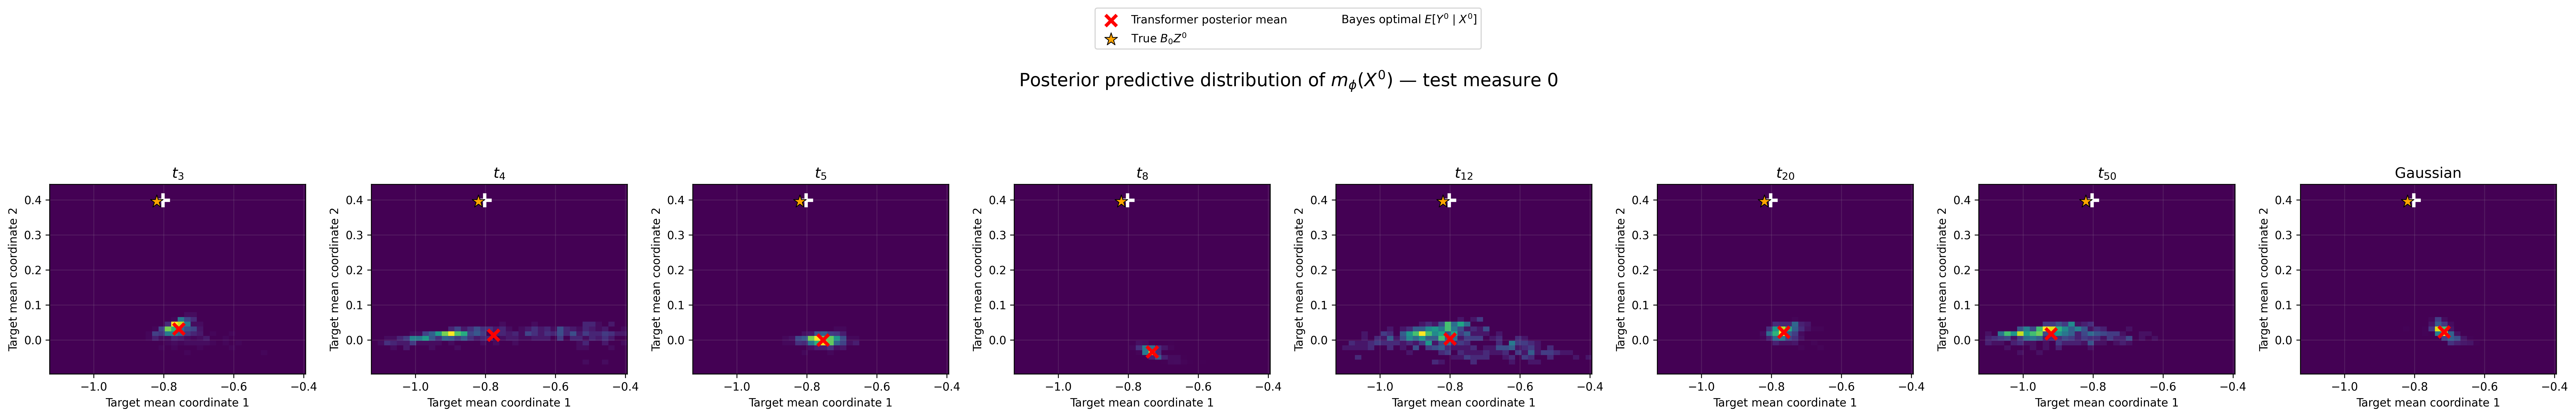

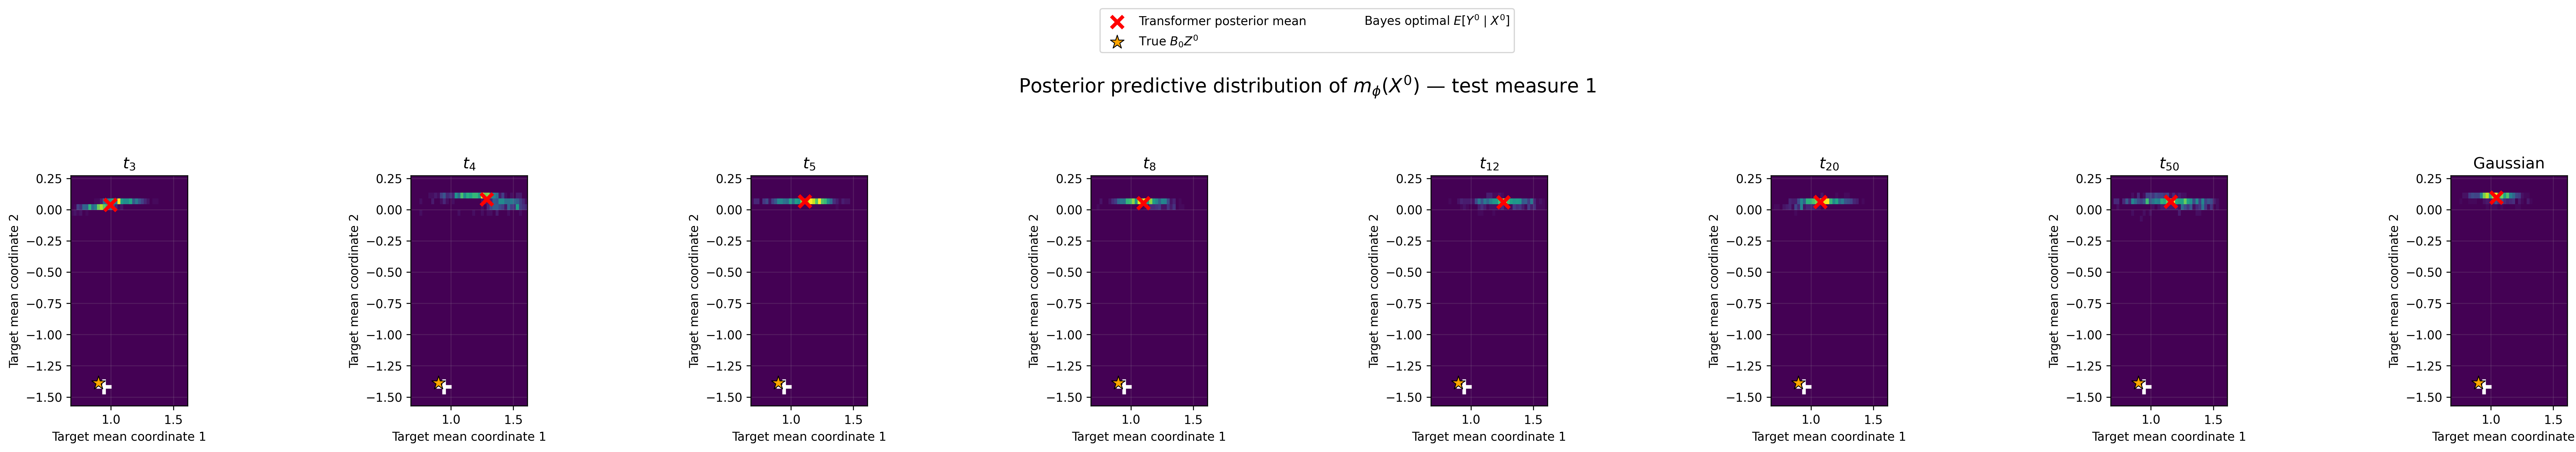

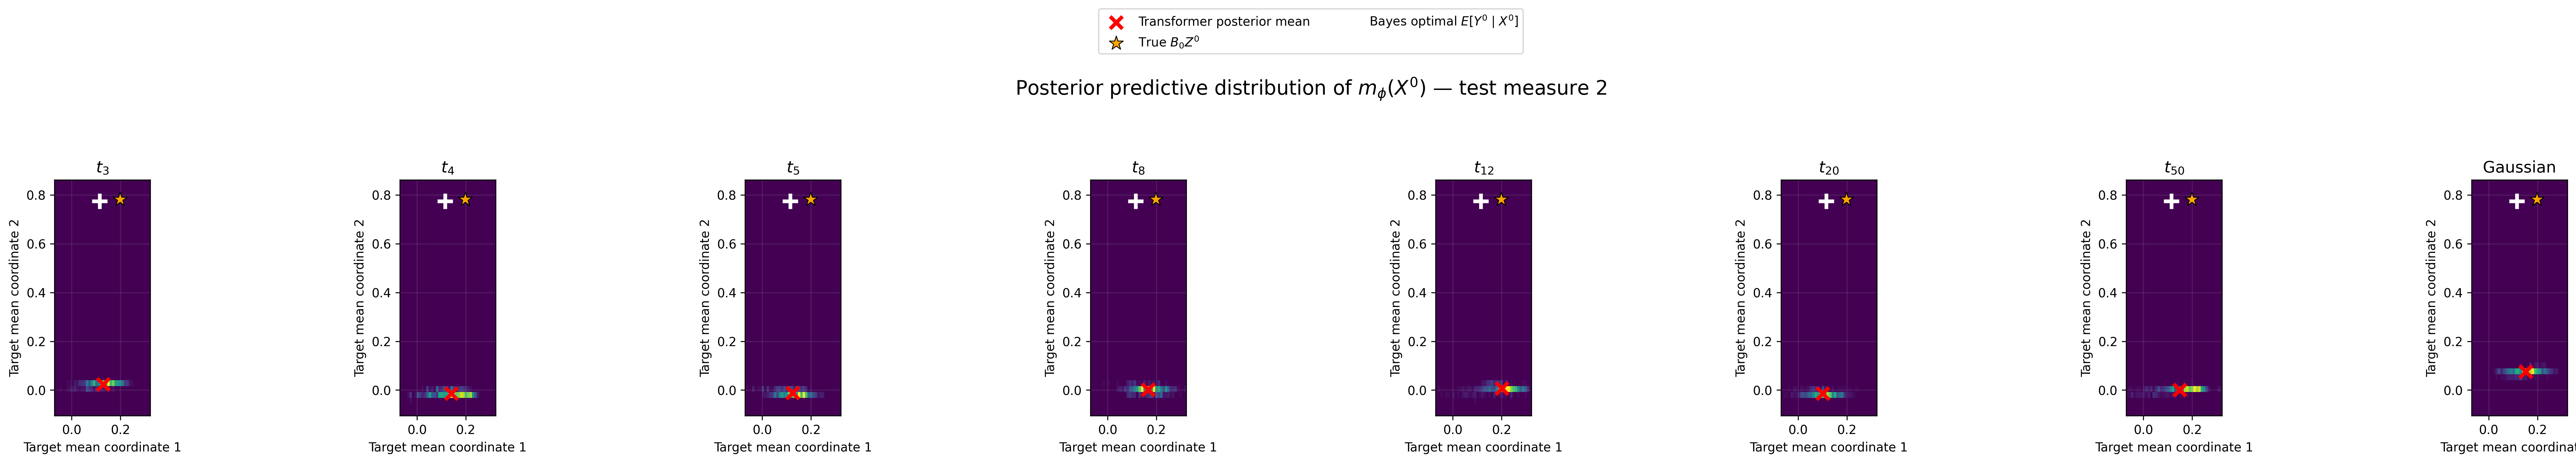

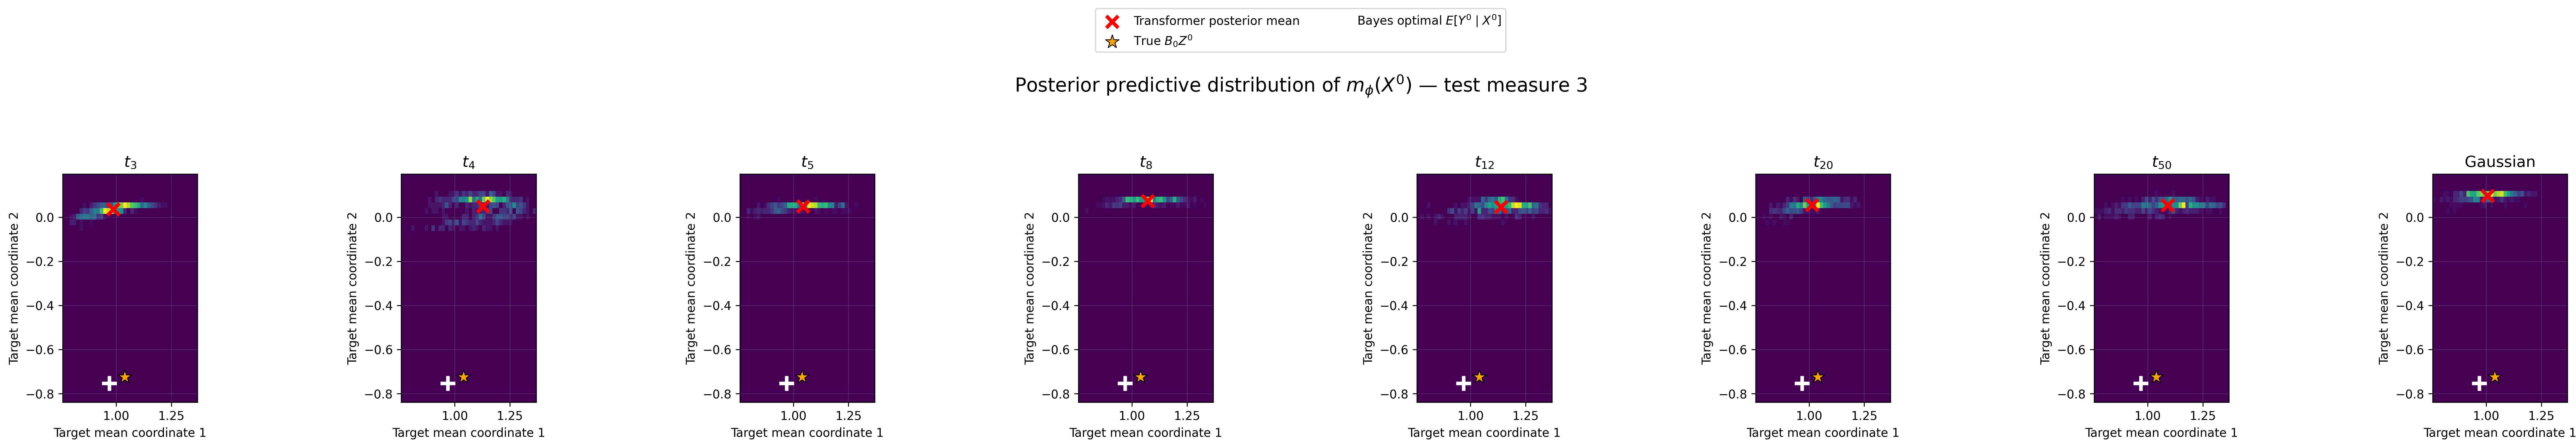

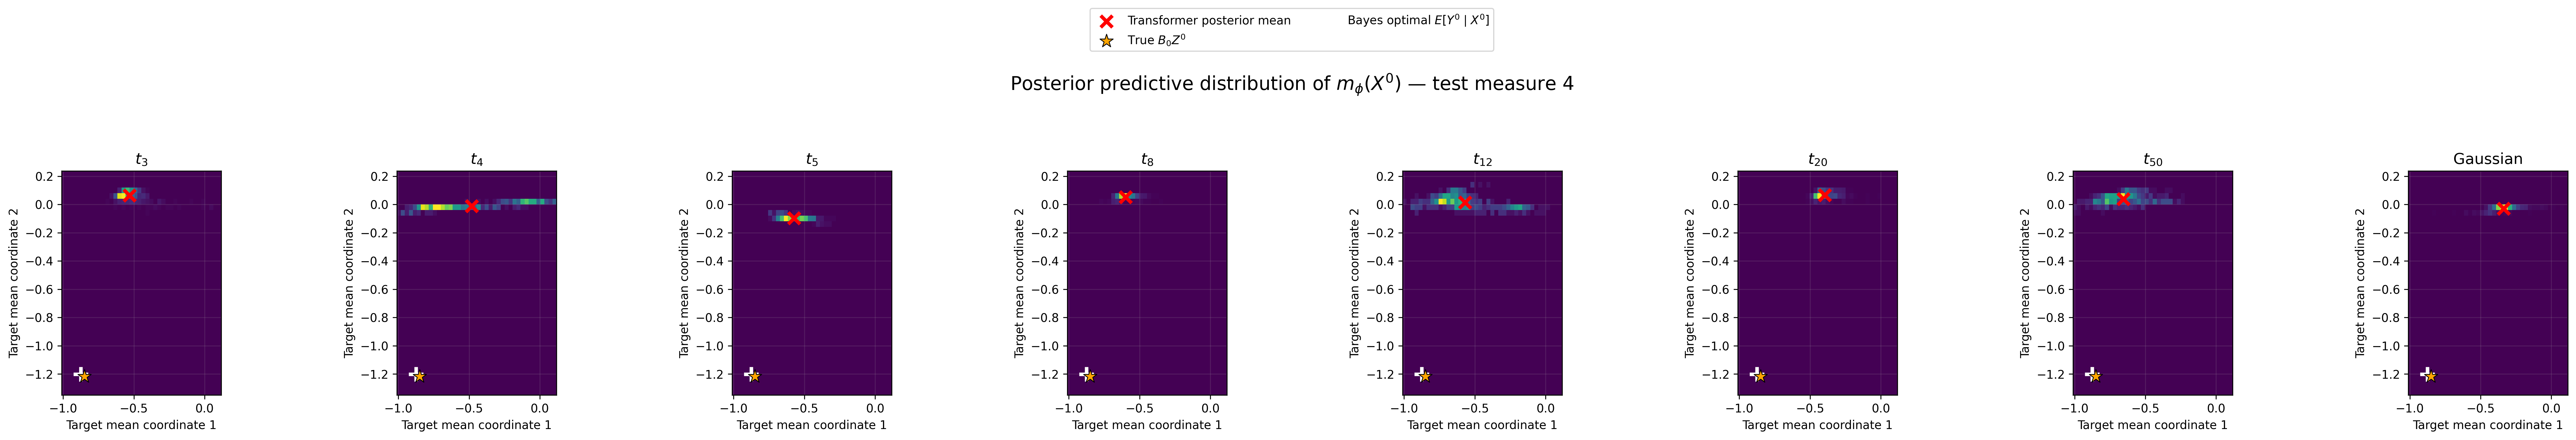

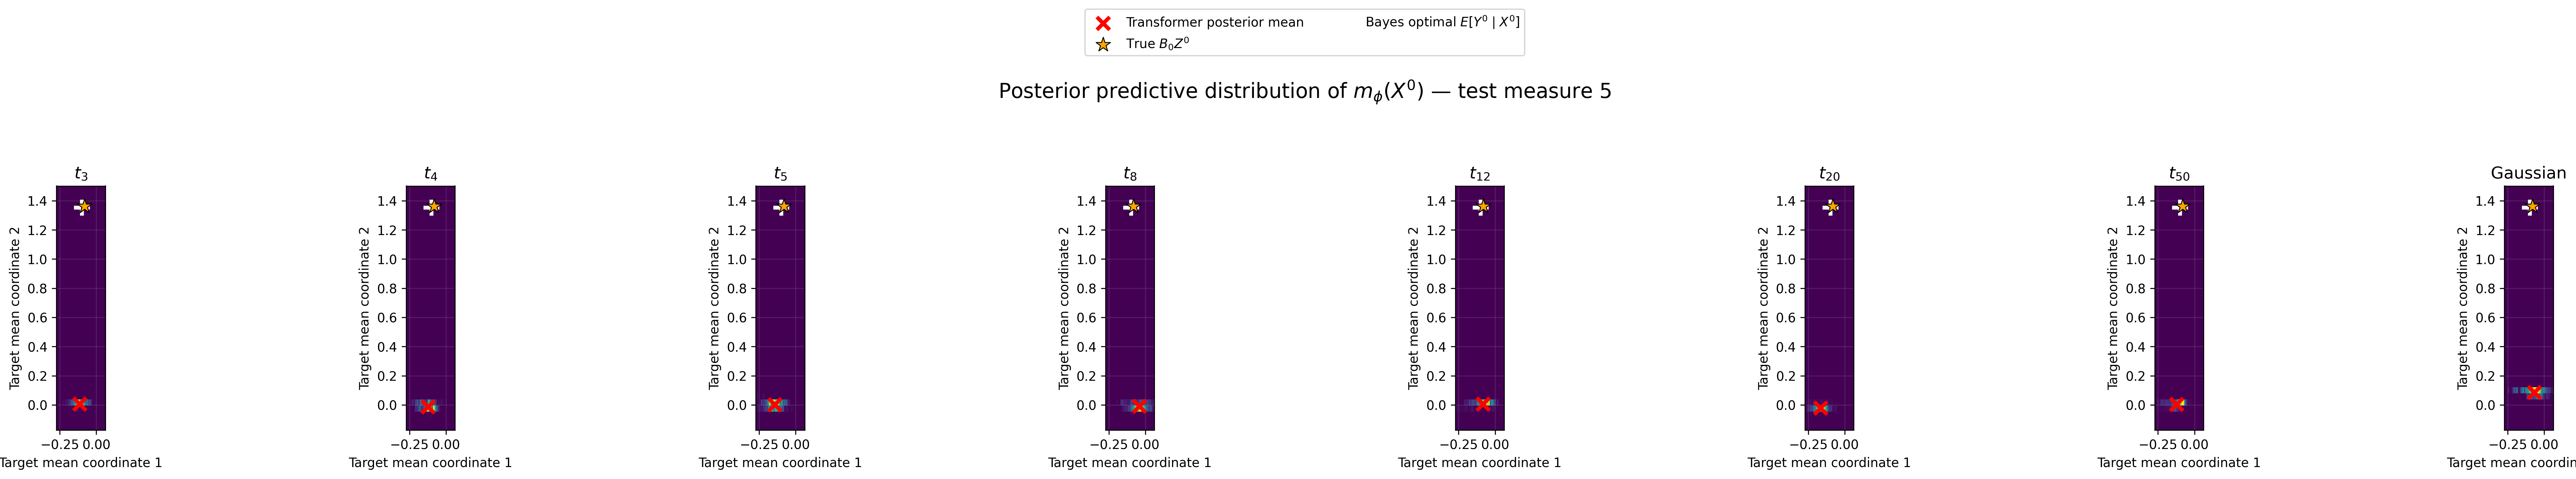

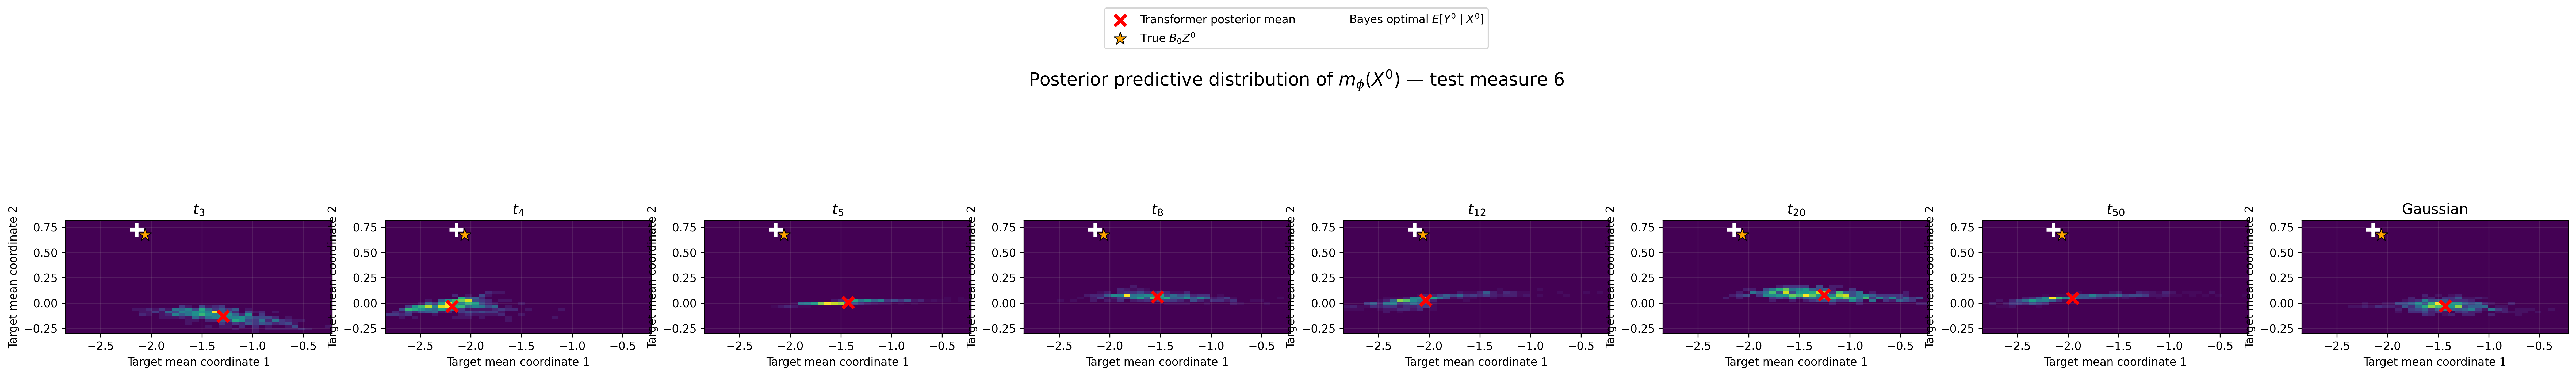

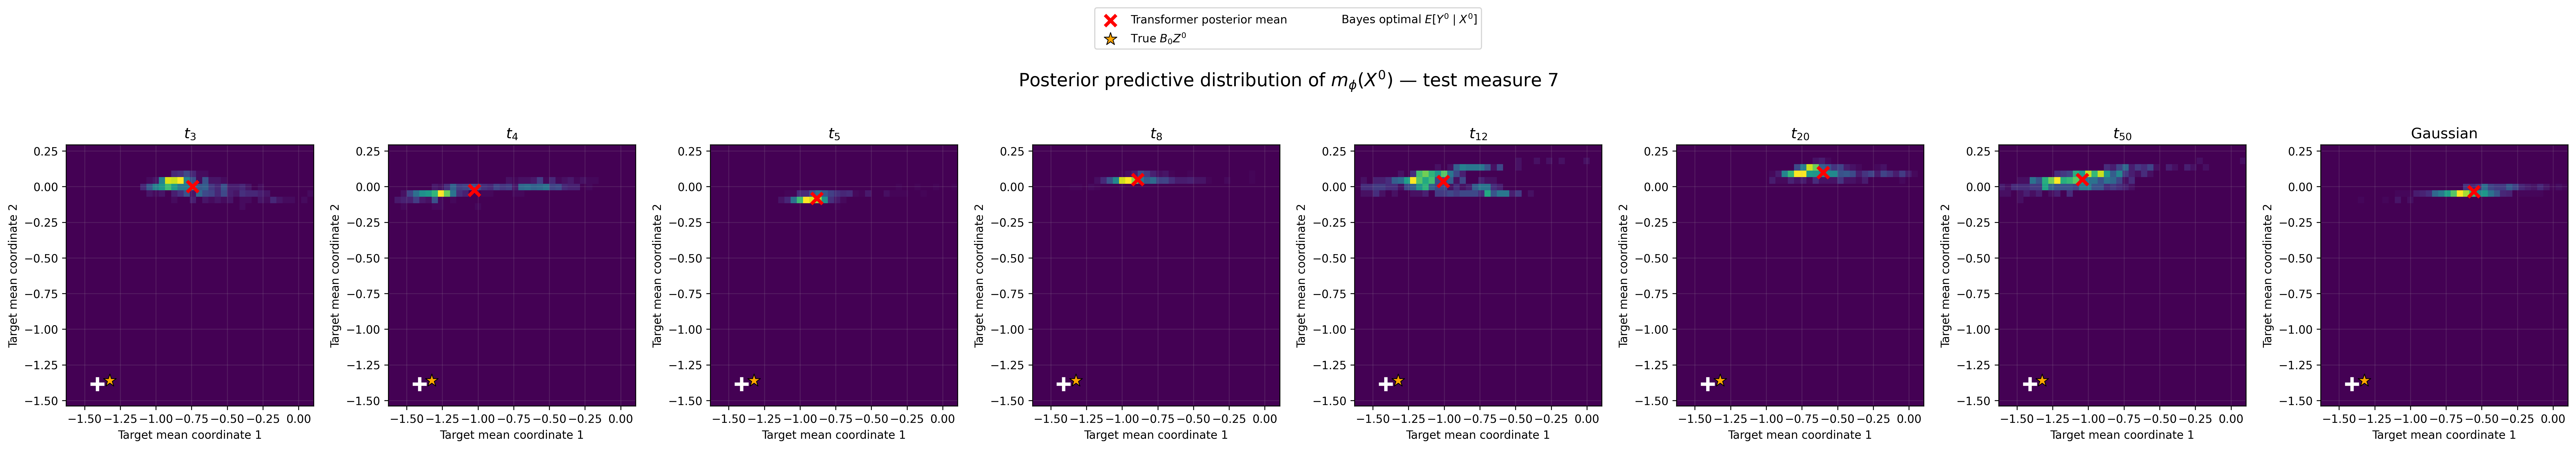

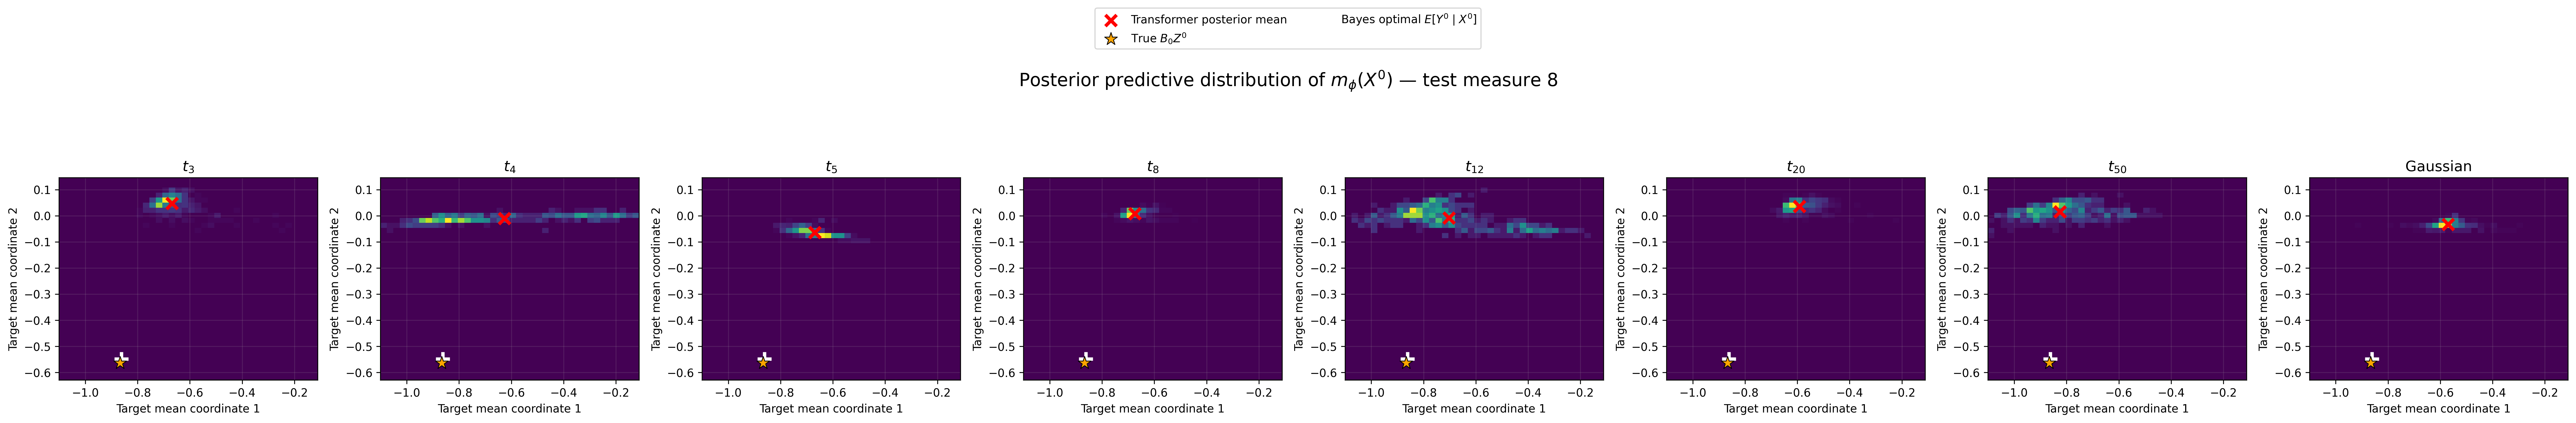

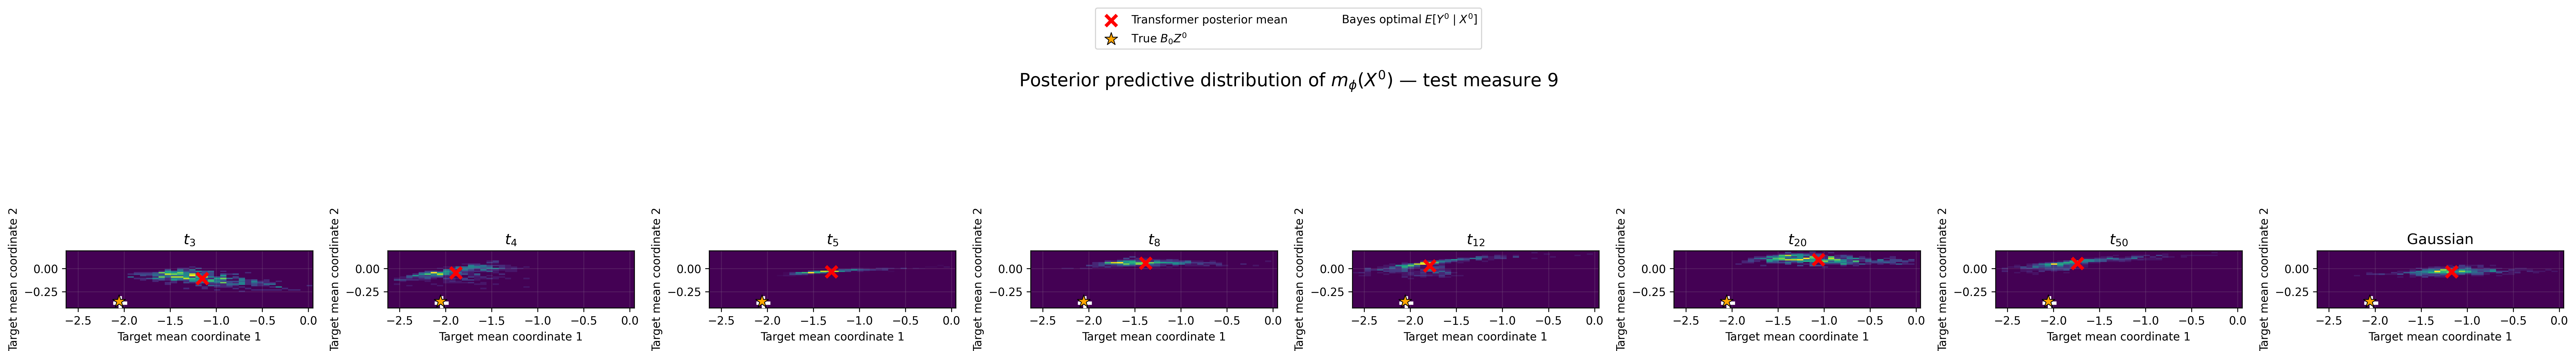

In [21]:
from IPython.display import display, Image

for measure_idx in range(n_plots):
    figure_path = (
        FIGURE_DIR
        / f"posterior_predictive_df_sweep_measure_{measure_idx}.png"
    )

    display(Image(
        filename=str(figure_path)
    ))

In [ ]:
metrics_script = (
    PROJECT_ROOT
    / "calculate_metrics.py"
)

if not metrics_script.exists():
    raise FileNotFoundError(
        f"Missing {metrics_script}"
    )

cmd = [
    sys.executable,
    "-u",
    str(metrics_script),
    "--checkpoint-dir",
    str(CHECKPOINT_DIR),
    "--figure-dir",
    str(FIGURE_DIR),
    "--n-test-measures",
    str(N_TEST_MEASURES),
    "--dfs",
    *[str(df) for df in T_DFs],
]

print(
    "Calculating df-sweep metrics...",
    flush=True,
)

process = subprocess.Popen(
    cmd,
    cwd=PROJECT_ROOT,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in process.stdout:
    print(
        line,
        end="",
        flush=True,
    )

return_code = process.wait()

if return_code != 0:
    raise subprocess.CalledProcessError(
        return_code,
        cmd,
    )

print(
    "Metric calculation and plotting finished.",
    flush=True,
)

## Output files

The experiment leaves these reusable files in `checkpoints/`:

- `fixed_D_and_X0.pt` — frozen training dataset and unseen test pair;
- `pca_subspace_fixed_D.pt` — SWA point and PCA subspace;
- `posterior_phi.pt` — ESS samples of \(\phi\);
- `posterior_predictive_X0.pt` — posterior samples of the target mean and one predictive point-cloud realization.
